# Compare Models: Reconstruction Errors and MST Metrics
Load summary JSON outputs created by notebook 11 and compare models.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [2]:
project_root = Path.cwd().resolve().parent
results_root = project_root / "results"

DATASET_NAME = "data_00_20_w724_s10"
dataset_dir = results_root / DATASET_NAME
analysis_dir = dataset_dir / "reconstruction_analysis"

if not dataset_dir.exists():
    available = [p.name for p in results_root.iterdir() if p.is_dir()]
    raise FileNotFoundError(f"Dataset not found: {dataset_dir}. Available: {available}")

if not analysis_dir.exists():
    raise FileNotFoundError(f"Missing reconstruction_analysis folder: {analysis_dir}")

model_dirs = sorted([p for p in analysis_dir.iterdir() if p.is_dir()])
model_names = [p.name for p in model_dirs]

print(f"Models found ({len(model_names)}): {model_names}")

Models found (11): ['AE_12dim_0005', 'AE_15dim_0003', 'AE_20dim_0004', 'AE_3dim_0003', 'AE_70dim_0005', 'linearAE_12dim_0003', 'linearAE_15dim_0002', 'linearAE_20dim_0001', 'linearAE_3dim_0001', 'linearAE_70dim_0001', 'PCA']


In [ ]:
def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def flatten_metric_stats(metrics_dict, prefix=""):
    flat = {}
    for metric, stats in metrics_dict.items():
        for stat, val in stats.items():
            key = f"{prefix}{metric}_{stat}"
            flat[key] = val
    return flat


def load_model_stats(model_dir: Path):
    records = []

    errors_path = model_dir / "reconstruction_errors.json"
    if errors_path.exists():
        payload = load_json(errors_path)

        if isinstance(payload, dict):
            record = {"model": model_dir.name}
            errors_block = payload.get("reconstruction_errors")
            mst_block = payload.get("mst_metrics")

            if errors_block is None and "MSE" in payload:
                errors_block = payload

            if errors_block is not None:
                record.update(flatten_metric_stats(errors_block, prefix="err_"))
            else:
                print(f"Missing reconstruction_errors block for {model_dir.name}")

            if mst_block is not None:
                record.update(flatten_metric_stats(mst_block, prefix="mst_"))
            else:
                print(f"Missing mst_metrics block for {model_dir.name}")

            records.append(record)
        elif isinstance(payload, list):
            if payload:
                sweep_df = pd.DataFrame(payload)
                for _, row in sweep_df.iterrows():
                    k = int(row["n_components"]) if "n_components" in row else None
                    model_name = f"{model_dir.name}_{k}" if k is not None else model_dir.name
                    record = {"model": model_name}

                    if "MSE_mean" in row:
                        record["err_MSE_mean"] = float(row["MSE_mean"])
                    if "MAE_mean" in row:
                        record["err_MAE_mean"] = float(row["MAE_mean"])
                    if "Frobenius_mean" in row:
                        record["err_Frobenius_mean"] = float(row["Frobenius_mean"])
                    if "mean_explained_variance" in row:
                        record["pca_mean_explained_variance"] = float(row["mean_explained_variance"])
                    if k is not None:
                        record["pca_selected_k"] = k

                    records.append(record)
            else:
                print(f"Empty reconstruction_errors list for {model_dir.name}")
        else:
            print(f"Unexpected reconstruction_errors format for {model_dir.name}")
    else:
        print(f"Missing reconstruction_errors.json for {model_dir.name}")

    return records

print(model_dirs)
records_nested = [load_model_stats(p) for p in model_dirs]
records = [record for sublist in records_nested for record in sublist]
stats_df = pd.DataFrame(records).set_index("model").sort_index()
stats_df

[WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_12dim_0005'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_15dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_20dim_0004'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_3dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/AE_70dim_0005'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGETTO_TESI_DYLAN/results/data_00_20_w724_s10/reconstruction_analysis/linearAE_12dim_0003'), WindowsPath('C:/Users/dylan/Desktop/TESI/SyntheticCorrelationVAE/PROGE

,err_MSE_mean,err_MSE_std,err_MSE_min,err_MSE_median,err_MSE_max,err_MAE_mean,err_MAE_std,err_MAE_min,err_MAE_median,err_MAE_max,err_Frobenius_mean,err_Frobenius_std,err_Frobenius_min,err_Frobenius_median,err_Frobenius_max,mst_edge_overlap_pct_count,mst_edge_overlap_pct_mean,mst_edge_overlap_pct_std,mst_edge_overlap_pct_min,mst_edge_overlap_pct_25%,mst_edge_overlap_pct_50%,mst_edge_overlap_pct_75%,mst_edge_overlap_pct_max,mst_edge_jaccard_pct_count,mst_edge_jaccard_pct_mean,...,mst_avg_path_len_unweighted_recon_mean,mst_avg_path_len_unweighted_recon_std,mst_avg_path_len_unweighted_recon_min,mst_avg_path_len_unweighted_recon_25%,mst_avg_path_len_unweighted_recon_50%,mst_avg_path_len_unweighted_recon_75%,mst_avg_path_len_unweighted_recon_max,mst_avg_path_len_unweighted_diff_count,mst_avg_path_len_unweighted_diff_mean,mst_avg_path_len_unweighted_diff_std,mst_avg_path_len_unweighted_diff_min,mst_avg_path_len_unweighted_diff_25%,mst_avg_path_len_unweighted_diff_50%,mst_avg_path_len_unweighted_diff_75%,mst_avg_path_len_unweighted_diff_max,mst_betweenness_topk_overlap_pct_count,mst_betweenness_topk_overlap_pct_mean,mst_betweenness_topk_overlap_pct_std,mst_betweenness_topk_overlap_pct_min,mst_betweenness_topk_overlap_pct_25%,mst_betweenness_topk_overlap_pct_50%,mst_betweenness_topk_overlap_pct_75%,mst_betweenness_topk_overlap_pct_max,pca_selected_k,pca_mean_explained_variance
model,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AE_12dim_0005,0.000400,0.000203,0.000131,0.000337,0.001048,0.014420,0.004167,0.007918,0.013593,0.024758,7.024080,1.790200,4.146532,6.645044,11.719884,41.0,77.420445,5.953463,65.096953,74.238227,77.562327,80.886427,88.365651,41.0,63.536394,...,10.670855,1.328256,8.803584,9.875622,10.423700,11.386740,14.065579,41.0,1.004443,0.638985,0.002525,0.410018,1.035782,1.497375,2.482438,41.0,61.707317,17.015058,30.0,50.0,60.0,70.0,100.0,NaN,NaN
AE_15dim_0003,0.000353,0.000160,0.000123,0.000343,0.000934,0.013667,0.003277,0.008419,0.013747,0.023312,6.654051,1.445686,4.021574,6.706769,11.063673,41.0,78.663604,5.407160,66.759003,75.623269,79.224377,81.994460,90.858726,41.0,65.149883,...,10.618373,1.506507,8.551690,9.354632,10.578565,11.596272,13.980166,41.0,1.025354,0.711874,0.063635,0.481658,0.993557,1.275248,2.710381,41.0,60.975610,16.401963,30.0,50.0,60.0,70.0,100.0,NaN,NaN
AE_20dim_0004,0.000322,0.000155,0.000110,0.000285,0.000876,0.012907,0.003424,0.008003,0.012205,0.022595,6.330421,1.472743,3.796505,6.107803,10.716578,41.0,79.994595,5.105719,69.252078,77.285319,80.055402,83.656510,91.135734,41.0,66.951725,...,10.806672,1.494572,8.808068,9.531504,10.470026,11.868352,14.139101,41.0,0.893902,0.735111,0.004836,0.195957,0.835984,1.391500,2.494146,41.0,65.365854,15.181825,30.0,50.0,70.0,80.0,100.0,NaN,NaN
AE_3dim_0003,0.000494,0.000231,0.000154,0.000490,0.001064,0.016088,0.004294,0.008775,0.015662,0.025010,7.826985,1.903885,4.490292,8.016822,11.808879,41.0,73.961219,5.899692,61.495845,68.975069,73.407202,77.285319,85.318560,41.0,59.026661,...,10.658260,1.407220,8.138581,9.797325,10.410891,11.172021,13.568234,41.0,0.915610,0.637764,0.070339,0.425399,0.900644,1.245634,2.942104,41.0,58.048780,16.003048,20.0,50.0,60.0,70.0,90.0,NaN,NaN
AE_70dim_0005,0.000275,0.000129,0.000122,0.000224,0.000701,0.011970,0.002990,0.008090,0.011185,0.020205,5.862486,1.328542,3.991955,5.418237,9.582605,41.0,81.102628,4.628407,70.360111,78.393352,81.717452,84.210526,91.412742,41.0,68.458859,...,10.776522,1.567438,8.071058,9.351954,10.592323,12.016360,13.619580,41.0,0.822871,0.807617,0.012228,0.192100,0.536065,1.320365,3.817144,41.0,64.634146,17.620664,20.0,50.0,70.0,80.0,100.0,NaN,NaN
PCA,0.000321,NaN,NaN,NaN,NaN,0.009977,NaN,NaN,NaN,NaN,6.391057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,0.761179
linearAE_12dim_0003,0.006622,0.002055,0.004231,0.005791,0.011474,0.062751,0.009393,0.050268,0.060016,0.083247,29.131615,4.430887,23.547432,27

In [4]:
err_metrics = ["MSE", "MAE", "Frobenius"]

available_err_metrics = [
    m for m in err_metrics if f"err_{m}_mean" in stats_df.columns
]
if not available_err_metrics:
    raise KeyError("No reconstruction error metrics found. Check JSON files.")

err_means = pd.DataFrame(
    {m: stats_df[f"err_{m}_mean"] for m in available_err_metrics},
    index=stats_df.index,
)
err_stds = pd.DataFrame(
    {m: stats_df[f"err_{m}_std"] for m in available_err_metrics},
    index=stats_df.index,
)

print("Reconstruction error means (lower is better):")
display(err_means.sort_values(available_err_metrics[0]))

print("Reconstruction error std:")
display(err_stds)

err_ranks = err_means.rank(axis=0, ascending=True)
err_ranks["avg_rank"] = err_ranks.mean(axis=1)
err_ranks = err_ranks.sort_values("avg_rank")

print("Reconstruction error rank (lower is better):")
display(err_ranks)

Reconstruction error means (lower is better):


,MSE,MAE,Frobenius
model,,,
linearAE_70dim_0001,0.000220,0.010807,5.257132
AE_70dim_0005,0.000275,0.011970,5.862486
linearAE_20dim_0001,0.000319,0.013093,6.349417
PCA,0.000321,0.009977,6.391057
AE_20dim_0004,0.000322,0.012907,6.330421
AE_15dim_0003,0.000353,0.013667,6.654051
AE_12dim_0005,0.000400,0.014420,7.024080
AE_3dim_0003,0.000494,0.016088,7.826985
linearAE_15dim_0002,0.002938,0.040871,19.091415


Reconstruction error std:


,MSE,MAE,Frobenius
model,,,
AE_12dim_0005,0.000203,0.004167,1.790200
AE_15dim_0003,0.000160,0.003277,1.445686
AE_20dim_0004,0.000155,0.003424,1.472743
AE_3dim_0003,0.000231,0.004294,1.903885
AE_70dim_0005,0.000129,0.002990,1.328542
PCA,NaN,NaN,NaN
linearAE_12dim_0003,0.002055,0.009393,4.430887
linearAE_15dim_0002,0.001587,0.010222,4.590457
linearAE_20dim_0001,0.000122,0.002946,1.245384


Reconstruction error rank (lower is better):


,MSE,MAE,Frobenius,avg_rank
model,,,,
linearAE_70dim_0001,1.0,2.0,1.0,1.333333
AE_70dim_0005,2.0,3.0,2.0,2.333333
PCA,4.0,1.0,5.0,3.333333
AE_20dim_0004,5.0,4.0,3.0,4.000000
linearAE_20dim_0001,3.0,5.0,4.0,4.000000
AE_15dim_0003,6.0,6.0,6.0,6.000000
AE_12dim_0005,7.0,7.0,7.0,7.000000
AE_3dim_0003,8.0,8.0,8.0,8.000000
linearAE_15dim_0002,9.0,9.0,9.0,9.000000


In [5]:
mst_metrics = [
    "edge_overlap_pct",
    "edge_jaccard_pct",
    "degree_l1",
    "avg_path_len_diff",
    "avg_path_len_unweighted_diff",
    "betweenness_topk_overlap_pct",
]

available_mst_metrics = [
    m for m in mst_metrics if f"mst_{m}_mean" in stats_df.columns
]
if not available_mst_metrics:
    raise KeyError("No MST metrics found. Check JSON files.")

mst_means = pd.DataFrame(
    {m: stats_df[f"mst_{m}_mean"] for m in available_mst_metrics},
    index=stats_df.index,
)

print("MST comparison means:")
display(mst_means)

higher_better = {"edge_overlap_pct", "edge_jaccard_pct", "betweenness_topk_overlap_pct"}
lower_better = {"degree_l1", "avg_path_len_diff", "avg_path_len_unweighted_diff"}


def rank_mst(df: pd.DataFrame):
    ranks = pd.DataFrame(index=df.index)
    for metric in df.columns:
        if metric in higher_better:
            ranks[metric] = df[metric].rank(ascending=False)
        else:
            ranks[metric] = df[metric].rank(ascending=True)
    ranks["avg_rank"] = ranks.mean(axis=1)
    return ranks.sort_values("avg_rank")


mst_ranks = rank_mst(mst_means)
print("MST rank (higher overlap is better, lower diffs are better):")
display(mst_ranks)

MST comparison means:


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct
model,,,,,,
AE_12dim_0005,77.420445,63.536394,0.088128,0.660982,1.004443,61.707317
AE_15dim_0003,78.663604,65.149883,0.092440,0.642034,1.025354,60.975610
AE_20dim_0004,79.994595,66.951725,0.087320,0.606665,0.893902,65.365854
AE_3dim_0003,73.961219,59.026661,0.091362,0.610784,0.915610,58.048780
AE_70dim_0005,81.102628,68.458859,0.088398,0.528136,0.822871,64.634146
PCA,NaN,NaN,NaN,NaN,NaN,NaN
linearAE_12dim_0003,37.477197,23.148506,0.131114,1.816119,1.433276,26.585366
linearAE_15dim_0002,47.483278,31.383419,0.124377,0.992468,1.486335,40.000000
linearAE_20dim_0001,78.940612,65.496047,0.090284,0.522534,0.872119,60.975610


MST rank (higher overlap is better, lower diffs are better):


,edge_overlap_pct,edge_jaccard_pct,degree_l1,avg_path_len_diff,avg_path_len_unweighted_diff,betweenness_topk_overlap_pct,avg_rank
model,,,,,,,
linearAE_70dim_0001,1.0,1.0,1.0,1.0,1.0,4.0,1.500000
AE_70dim_0005,2.0,2.0,4.0,3.0,2.0,2.0,2.500000
AE_20dim_0004,3.0,3.0,2.0,4.0,4.0,1.0,2.833333
linearAE_20dim_0001,4.0,4.0,5.0,2.0,3.0,5.5,3.916667
AE_12dim_0005,6.0,6.0,3.0,7.0,6.0,3.0,5.166667
AE_15dim_0003,5.0,5.0,7.0,6.0,7.0,5.5,5.916667
AE_3dim_0003,7.0,7.0,6.0,5.0,5.0,7.0,6.166667
linearAE_15dim_0002,8.0,8.0,8.0,8.0,9.0,8.0,8.166667
linearAE_12dim_0003,9.0,9.0,9.0,10.0,8.0,10.0,9.166667


In [6]:
summary = pd.DataFrame(index=stats_df.index)
summary["err_score"] = err_ranks["avg_rank"]
summary["mst_score"] = mst_ranks["avg_rank"]
summary["combined_score"] = summary.mean(axis=1)
summary = summary.sort_values("combined_score")

print("Combined score (lower is better):")
display(summary)

Combined score (lower is better):


,err_score,mst_score,combined_score
model,,,
linearAE_70dim_0001,1.333333,1.500000,1.416667
AE_70dim_0005,2.333333,2.500000,2.416667
PCA,3.333333,NaN,3.333333
AE_20dim_0004,4.000000,2.833333,3.416667
linearAE_20dim_0001,4.000000,3.916667,3.958333
AE_15dim_0003,6.000000,5.916667,5.958333
AE_12dim_0005,7.000000,5.166667,6.083333
AE_3dim_0003,8.000000,6.166667,7.083333
linearAE_15dim_0002,9.000000,8.166667,8.583333


# K-based comparison plots
Build plots for error metrics across K and methods.

In [7]:
import re


def parse_model_name(model_name: str):
    method_raw = model_name.split("_")[0]
    method_map = {"pca": "PCA", "linearae": "linearAE", "ae": "AE"}
    method = method_map.get(method_raw.lower(), method_raw)

    match = re.search(r"(\d+)\s*dim", model_name, flags=re.IGNORECASE)
    if not match:
        match = re.search(r"_(\d+)(?:_|$)", model_name)
    k = int(match.group(1)) if match else None

    return method, k


model_meta = []
for model in stats_df.index:
    method, k = parse_model_name(model)
    model_meta.append({"model": model, "method": method, "K": k})

meta_df = pd.DataFrame(model_meta).set_index("model")

err_by_model = err_means.join(meta_df)
err_by_model = err_by_model.dropna(subset=["K", "method"]).copy()
err_by_model["K"] = err_by_model["K"].astype(int)

if err_by_model.empty:
    raise ValueError("No valid models with parsed K were found.")

err_long = err_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_err_metrics,
    var_name="metric",
    value_name="error",
)

pca_sweep_path = project_root / "results" / f"{DATASET_NAME}" / "reconstruction_analysis" / "PCA" / "reconstruction_errors.json"
if pca_sweep_path.exists():
    pca_payload = load_json(pca_sweep_path)
    if isinstance(pca_payload, dict) and "sweep" in pca_payload:
        pca_rows = pca_payload["sweep"]
    elif isinstance(pca_payload, list):
        pca_rows = pca_payload
    else:
        pca_rows = []
        print(f"Unexpected PCA sweep format in {pca_sweep_path.name}")

    pca_df = pd.DataFrame(pca_rows)
    if not pca_df.empty:
        pca_long_parts = []
        for metric in available_err_metrics:
            metric_col = f"{metric}_mean"
            if metric_col not in pca_df.columns:
                continue
            part = pca_df[["n_components", metric_col]].rename(
                columns={"n_components": "K", metric_col: "error"}
            )
            part["metric"] = metric
            part["method"] = "PCA"
            pca_long_parts.append(part)
        if pca_long_parts:
            pca_long = pd.concat(pca_long_parts, ignore_index=True)
            pca_long["K"] = pca_long["K"].astype(int)
            err_long = pd.concat([err_long, pca_long], ignore_index=True)
            err_long = err_long.drop_duplicates(
                subset=["method", "K", "metric"],
                keep="last",
            )
        else:
            print(f"No matching PCA metrics found in {pca_sweep_path.name}")
    else:
        print(f"PCA sweep file is empty: {pca_sweep_path}")
else:
    print(f"PCA sweep file not found: {pca_sweep_path}")

method_order = ["PCA", "linearAE", "AE"]
methods = [m for m in method_order if m in err_long["method"].unique()]
if not methods:
    methods = sorted(err_long["method"].unique())

ks_sorted = sorted(err_long["K"].unique())

method_labels = {"PCA": "PCA", "linearAE": "LinearAE", "AE": "AE"}
method_colors = {"PCA": "tab:blue", "linearAE": "tab:green", "AE": "tab:red"}

print(f"Methods: {methods}")
print(f"K values: {ks_sorted}")

Methods: ['PCA', 'linearAE', 'AE']
K values: [np.int64(3), np.int64(12), np.int64(15), np.int64(20), np.int64(70)]


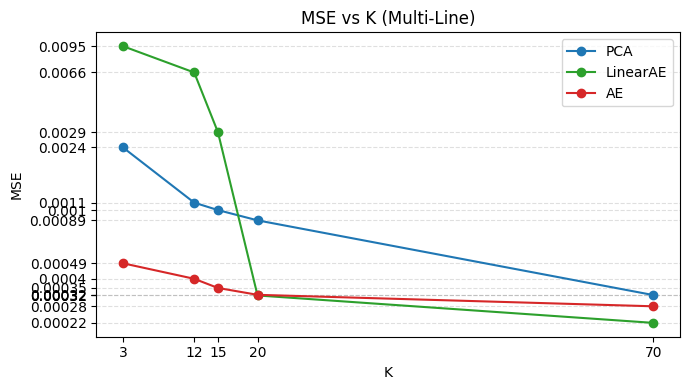

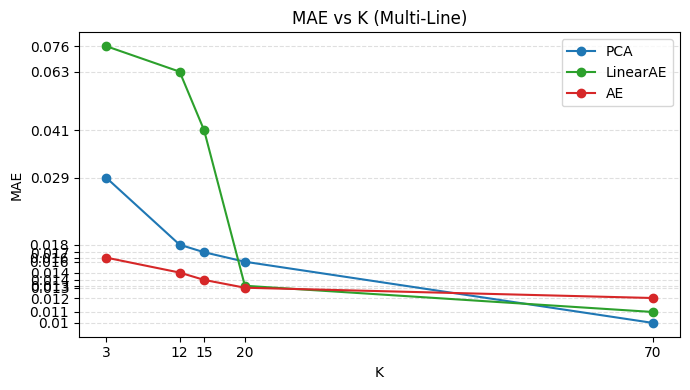

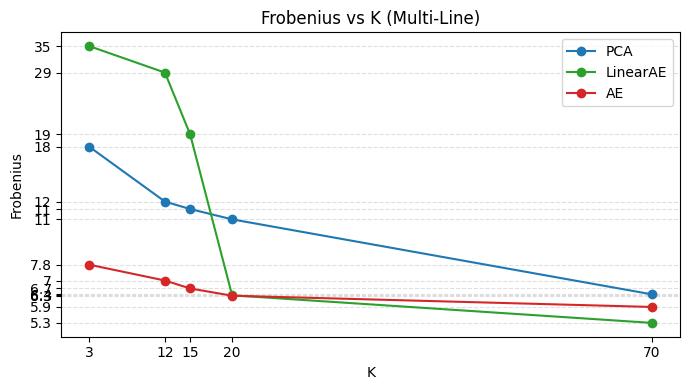

In [8]:
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

for metric in available_err_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    all_x = []
    all_y = []
    for method in methods:
        subset = err_long[
            (err_long["metric"] == metric) & (err_long["method"] == method)
        ].sort_values("K")
        x_vals = subset["K"].to_numpy()
        y_vals = subset["error"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_yscale("log")
    if all_x:
        ax.set_xticks(sorted(set(all_x)))
    if all_y:
        y_ticks = sorted(set(all_y))
        ax.yaxis.set_major_locator(FixedLocator(y_ticks))
        ax.yaxis.set_major_formatter(FixedFormatter([f"{v:.2g}" for v in y_ticks]))
        ax.yaxis.set_minor_locator(NullLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

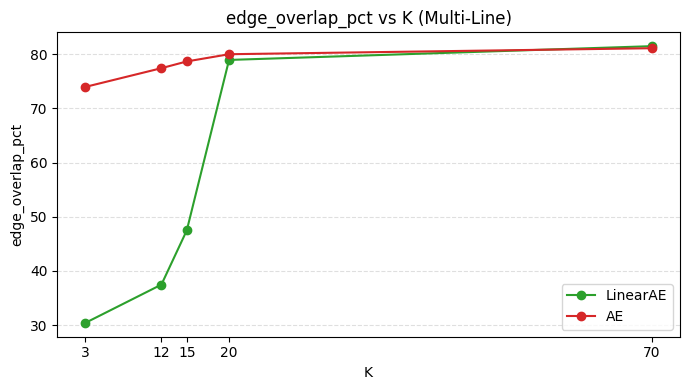

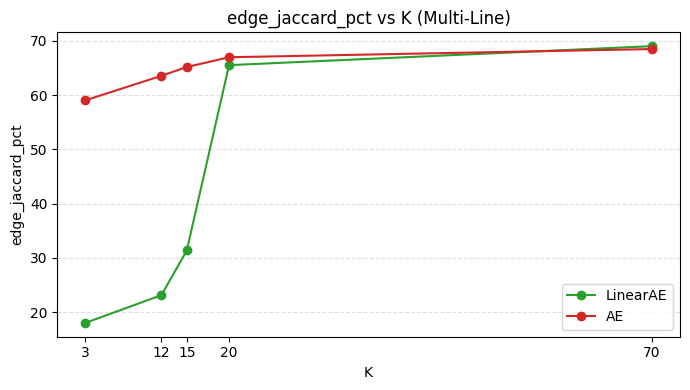

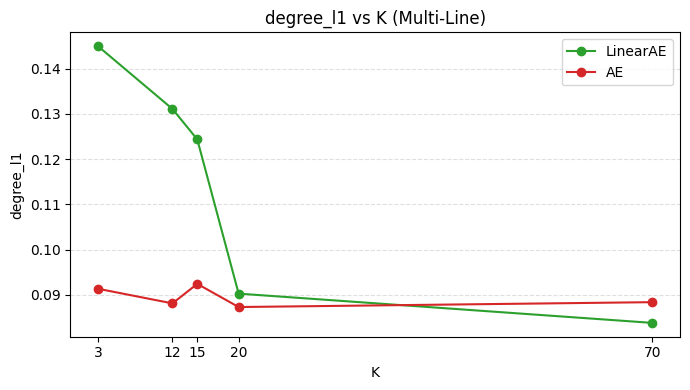

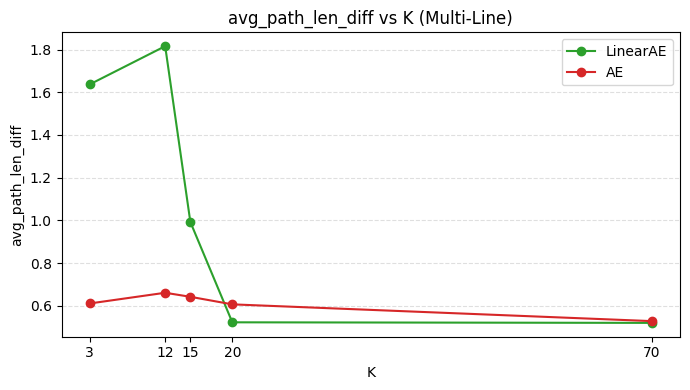

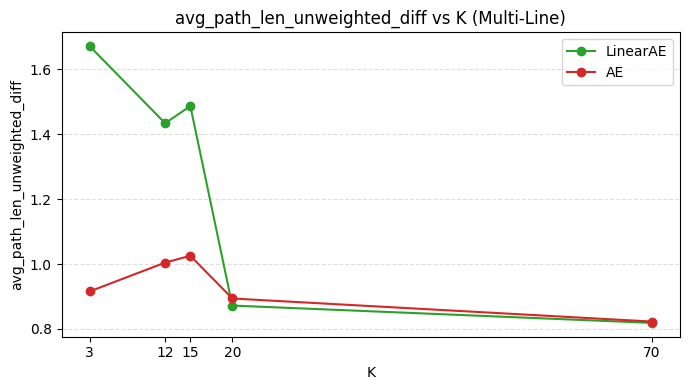

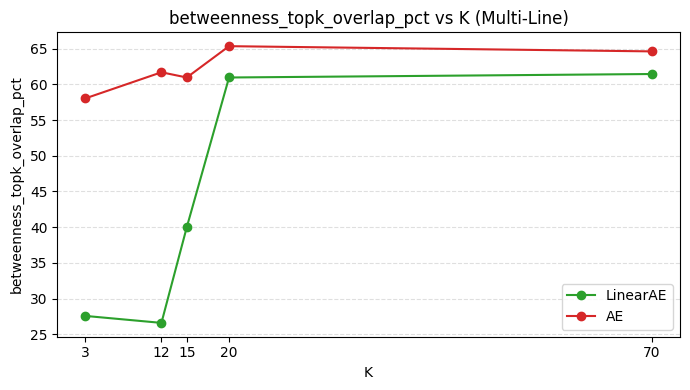

In [9]:
# MST K-based comparison plots
mst_by_model = mst_means.join(meta_df)
mst_by_model = mst_by_model.dropna(subset=["K", "method"]).copy()
mst_by_model["K"] = mst_by_model["K"].astype(int)

if mst_by_model.empty:
    raise ValueError("No valid MST models with parsed K were found.")

mst_long = mst_by_model.melt(
    id_vars=["method", "K"],
    value_vars=available_mst_metrics,
    var_name="metric",
    value_name="value",
)

mst_methods = [m for m in method_order if m in mst_long["method"].unique()]
if not mst_methods:
    mst_methods = sorted(mst_long["method"].unique())

mst_ks_sorted = sorted(mst_long["K"].unique())

for metric in available_mst_metrics:
    fig, ax = plt.subplots(figsize=(7, 4))
    all_x = []
    all_y = []
    for method in mst_methods:
        subset = mst_long[
            (mst_long["metric"] == metric) & (mst_long["method"] == method)
        ].sort_values("K")
        if subset.empty:
            continue
        x_vals = subset["K"].to_numpy()
        y_vals = subset["value"].to_numpy()
        all_x.extend(x_vals.tolist())
        all_y.extend(y_vals.tolist())
        ax.plot(
            x_vals,
            y_vals,
            marker="o",
            label=method_labels.get(method, method),
            color=method_colors.get(method),
        )

    ax.set_title(f"{metric} vs K (Multi-Line)")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    if all_x:
        ax.set_xticks(sorted(set(all_x)))
    if all_y:
        y_min = min(all_y)
        y_max = max(all_y)
        if y_min > 0 and (y_max / y_min) >= 1000:
            ax.set_yscale("log")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

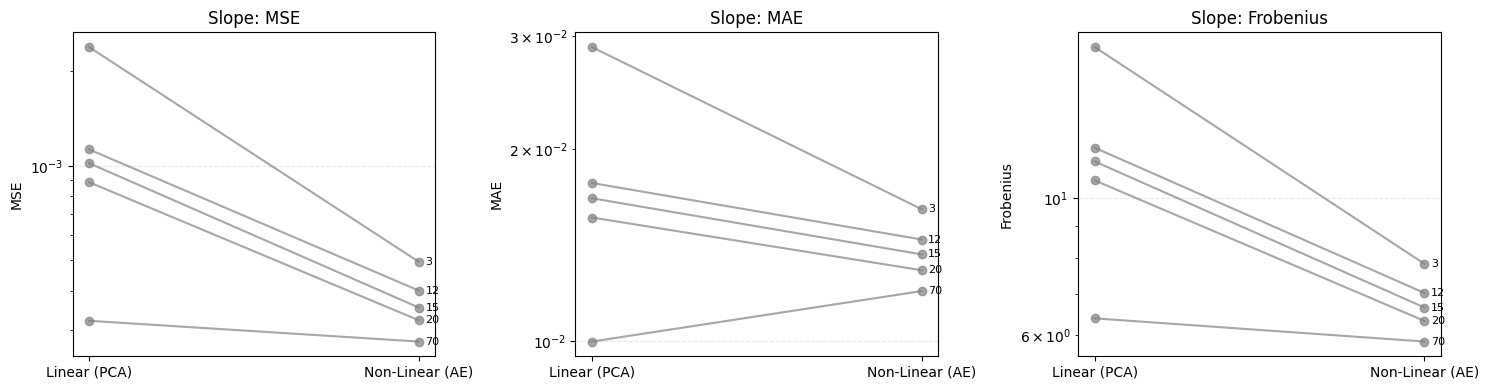

In [10]:
linear_candidates = ["PCA", "linearAE"]
linear_method = next((m for m in linear_candidates if m in methods), None)
nonlinear_method = "AE" if "AE" in methods else None

if linear_method is None or nonlinear_method is None:
    print("Slope chart skipped: need both a linear method (PCA or linearAE) and AE.")
else:
    fig, axes = plt.subplots(1, len(available_err_metrics), figsize=(5 * len(available_err_metrics), 4))
    if len(available_err_metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, available_err_metrics):
        pivot = (
            err_long[err_long["metric"] == metric]
            .pivot(index="K", columns="method", values="error")
            .reindex(index=ks_sorted)
        )

        for k in ks_sorted:
            if (
                k in pivot.index
                and linear_method in pivot.columns
                and nonlinear_method in pivot.columns
            ):
                y1 = pivot.loc[k, linear_method]
                y2 = pivot.loc[k, nonlinear_method]
                if pd.notna(y1) and pd.notna(y2):
                    ax.plot([0, 1], [y1, y2], marker="o", color="gray", alpha=0.7)
                    if len(ks_sorted) <= 10:
                        ax.text(1.02, y2, str(k), va="center", fontsize=8)

        ax.set_title(f"Slope: {metric}")
        ax.set_xticks([0, 1])
        ax.set_xticklabels([
            f"Linear ({method_labels.get(linear_method, linear_method)})",
            "Non-Linear (AE)",
        ])
        ax.set_ylabel(metric)
        ax.set_yscale("log")
        ax.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()